# Logistic Regression with Horseshoe Prior

This notebook mirrors the sampler comparison in `multivariate_probit.ipynb`, but uses the sparse logistic regression posterior with a horseshoe prior from `experiments.targets.LogisticRegressionHorseshoe`.

For observations $i=1,\ldots,n$,
$$
Y_i \mid X_i, \beta \sim \mathrm{Bernoulli}(\sigma(X_i^\top\beta)), \qquad \sigma(t)=\frac{1}{1+e^{-t}}.
$$
The prior is the horseshoe hierarchy
$$
\beta_j \mid \lambda_j, \tau \sim N(0, \tau^2\lambda_j^2), \qquad \lambda_j \sim C^+(0,1), \qquad \tau \sim C^+(0,1).
$$
The target is parameterized by the unconstrained state `(beta, log_lambda_local, log_tau_global)`.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import HMC, MCMC, NUTS
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import trange
from polyagamma import random_polyagamma

from src.cauchy_mh import independent_cauchy_mh
from src.scp_core import SCP
from experiments.targets import LogisticRegressionHorseshoe

numpyro.set_host_device_count(20)

/Users/sl933/Dropbox/Projects/Sub-Cauchy sampling/sub-cauchy-sampler/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
jax.__version__

'0.5.2'

### Generate Synthetic Data and Set Up Target

In [2]:
p = 20
n = 50

X = jax.random.normal(jax.random.PRNGKey(2025), (n, p - 1))
X -= jnp.mean(X, axis=0)
X /= jnp.std(X, axis=0)
X *= 0.5
X = jnp.hstack([jnp.ones((n, 1)), X])
y = (X[:, 1] > 0.).astype(jnp.float32)

target = LogisticRegressionHorseshoe(X, y)
d = target.d
print("X shape:", X.shape)
print("y shape:", y.shape)
print("state dimension:", target.d)
print("event rate:", float(jnp.mean(y)))
print("initial log_prob:", float(target.log_prob(target.initial_state())))

X shape: (50, 20)
y shape: (50,)
state dimension: 41
event rate: 0.5199999809265137
initial log_prob: -49.213462829589844


In [3]:
state0 = target.initial_state()
beta0, log_lambda0, log_tau0 = target.unpack(state0)

print("initial state shape:", state0.shape)
print("beta shape:", beta0.shape)
print("log_lambda_local shape:", log_lambda0.shape)
print("log_tau_global shape:", jnp.shape(log_tau0))
print("initial log_prob finite:", bool(jnp.isfinite(target.log_prob(state0))))

initial state shape: (41,)
beta shape: (20,)
log_lambda_local shape: (20,)
log_tau_global shape: ()
initial log_prob finite: True


### NUTS

In [ ]:
num_chains = 4
nuts_kernel = NUTS(potential_fn=lambda state: -target.log_prob(state))
nuts_mcmc = MCMC(
    nuts_kernel,
    num_warmup=1000,
    num_samples=10000,
    thinning=1,
    num_chains=num_chains,
    progress_bar=True,
)
init_params = jnp.tile(state0, (num_chains, 1))
nuts_mcmc.run(
    jax.random.key(0),
    init_params=init_params,
    extra_fields=("accept_prob",),
)

nuts_samples = nuts_mcmc.get_samples()
nuts_beta_samples = target.extract_beta(nuts_samples)
nuts_accept_rate = jnp.mean(nuts_mcmc.get_extra_fields()["accept_prob"])

print("NUTS acceptance rate:", float(nuts_accept_rate))
print("NUTS sample shape:", nuts_samples.shape)
print("NUTS beta sample shape:", nuts_beta_samples.shape)

Compiling.. :   0%|          | 0/11000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/11000 [00:00<?, ?it/s]





Running chain 0:   5%|▌         | 550/11000 [00:01<00:12, 842.07it/s]


Running chain 0:  10%|█         | 1100/11000 [00:01<00:12, 785.26it/s]





Running chain 0:  15%|█▌        | 1650/11000 [00:03<00:17, 545.94it/s]



Running chain 0:  20%|██        | 2200/11000 [00:04<00:18, 473.96it/s]





Running chain 0:  25%|██▌       | 2750/11000 [00:05<00:18, 440.26it/s]





Running chain 0:  30%|███       | 3300/11000 [00:07<00:17, 434.54it/s]




### HMC

In [67]:
hmc_kernel = HMC(
    potential_fn=lambda state: -target.log_prob(state),
    step_size=0.5,
    adapt_step_size=True,
    adapt_mass_matrix=False,
    num_steps=10,
    trajectory_length=None,
)
hmc_mcmc = MCMC(
    hmc_kernel,
    num_warmup=100,
    num_samples=500_000,
    thinning=50,
    num_chains=1,
)
hmc_mcmc.run(
    jax.random.key(0),
    init_params=jnp.zeros(target.d),
    extra_fields=("accept_prob",),
)

hmc_samples = hmc_mcmc.get_samples()
hmc_beta_samples = target.extract_beta(hmc_samples)
hmc_accept_rate = jnp.mean(hmc_mcmc.get_extra_fields()["accept_prob"])

print("HMC acceptance rate:", float(hmc_accept_rate))
print("HMC sample shape:", hmc_samples.shape)
print("HMC beta sample shape:", hmc_beta_samples.shape)

sample: 100%|██████████| 500100/500100 [00:48<00:00, 10347.29it/s, 10 steps of size 2.87e-02. acc. prob=0.72]

HMC acceptance rate: 0.7187092304229736
HMC sample shape: (10000, 41)
HMC beta sample shape: (10000, 20)


### Independent Cauchy MH

In [68]:
cauchy_samples, cauchy_accept_rate = independent_cauchy_mh(
    target.log_prob,
    jnp.zeros(target.d),
    jax.random.key(0),
    nsample=500_000,
    burnin=100,
    thinning=50,
    stepsize=0.01,
)

cauchy_beta_samples = target.extract_beta(cauchy_samples)

print("Independent Cauchy MH acceptance rate:", float(cauchy_accept_rate))
print("Independent Cauchy MH sample shape:", cauchy_samples.shape)
print("Independent Cauchy MH beta sample shape:", cauchy_beta_samples.shape)

Running for 500,100 iterations: 100%|██████████| 500100/500100 [00:06<00:00, 71448.70it/s]

Independent Cauchy MH acceptance rate: 0.0
Independent Cauchy MH sample shape: (10000, 41)
Independent Cauchy MH beta sample shape: (10000, 20)


### SCP

In [4]:
scp_model = SCP(
    d=target.d,
    latitude=1.7,
    affine='covariance',
)

opt_params, losses = scp_model.minimize_reverse_kl(
    target.log_prob,
    seed=1,
    ntrain=256,
    max_iter=1000,
    learning_rate=0.01,
    clip_value=100.,
)

print("final SCP training loss:", float(losses[-1]))

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 3497.56it/s]


final SCP training loss: -27.478403091430664


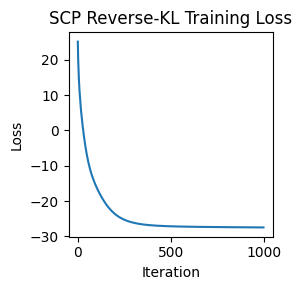

In [5]:
plt.figure(figsize=(3, 3))
plt.plot(losses)
plt.title("SCP Reverse-KL Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [6]:
u0 = scp_model.inverse_projection(opt_params, target.initial_state())
reprojected_state = scp_model.projection(opt_params, u0)

print("sphere state shape:", u0.shape)
print("reprojected log_prob:", float(target.log_prob(reprojected_state)))

sphere state shape: (42,)
reprojected log_prob: -49.21338653564453


In [7]:
scp_samples, scp_accept_rate = scp_model.rwm_bright_side(
    target.log_prob,
    opt_params,
    seed=0,
    x0=u0,
    stepsize=0.003,
    nsample=5_000_000,
    burnin=100,
    thinning=500,
    algo='stepout',
)
print("SCP acceptance rate:", float(scp_accept_rate))

Running for 5,000,100 iterations: 100%|██████████| 5000100/5000100 [00:48<00:00, 102347.42it/s]


SCP acceptance rate: 0.34109997749328613


In [8]:
savepath = "experiments/results/20260504/logistic_horseshoe/logistic_horseshoe_d20_n50_affinecovariance_lat1.7_stepsize0.005_n500000_seed0_quantiles.csv"
results = pd.read_csv(savepath, index_col=0)
results['NUTS1']

0.01      26.581112
0.02      33.299538
0.05      46.948338
0.10      70.996280
0.20     124.751620
0.50     394.206970
0.80    1335.368000
0.90    2181.620000
0.95    3058.250200
0.98    4115.500500
0.99    5162.964400
Name: NUTS1, dtype: float64

In [11]:
jnp.quantile(scp_samples[:, 1], jnp.array([0.95, 0.98, 0.99]))

Array([2095.1353, 3874.501 , 4657.3438], dtype=float32)

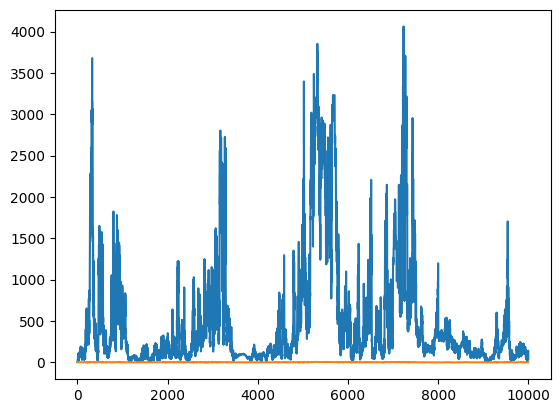

In [110]:
# scp_beta_samples, scp_log_lambda_samples, scp_log_tau_samples = target.unpack(scp_samples)

# print("SCP acceptance rate:", float(scp_accept_rate))
# print("SCP sample shape:", scp_samples.shape)
# print("SCP beta sample shape:", scp_beta_samples.shape)

plt.plot(scp_samples[:, 1])
# plt.plot(scp_samples[:, 2])
plt.plot(scp_samples[:, -1])

### Gibbs Sampler

In [69]:
import time

gibbs_nsample = 500_000
gibbs_burnin = 100
gibbs_thinning = 50

rng = np.random.default_rng(0)
X_np = np.asarray(X, dtype=float)
y_np = np.asarray(y, dtype=float)

n_obs, p = X_np.shape
kappa = y_np - 0.5

# Initialize parameters
beta = np.zeros(p)
lambda_sq = np.ones(p)   # lambda_j^2
tau_sq = 1.0             # tau^2
nu = np.ones(p)          # auxiliary for lambda
xi = 1.0                 # auxiliary for tau

total_iters = gibbs_burnin + gibbs_nsample
gibbs_samples = np.zeros((gibbs_nsample // gibbs_thinning, d))

start = time.time()
sample_idx = 0
for t in trange(total_iters):
    # 1. Sample omega_i | beta  ~  PG(1, x_i^T beta)
    eta = X_np @ beta
    omega = random_polyagamma(np.ones(n_obs), eta, random_state=rng)

    # 2. Sample beta | omega, lambda, tau, y
    prior_prec = 1.0 / (tau_sq * lambda_sq)
    WX = X_np * omega[:, None]
    XtWX = X_np.T @ WX
    P = XtWX + np.diag(prior_prec)
    L = np.linalg.cholesky(P)
    rhs = X_np.T @ kappa
    m = np.linalg.solve(L.T, np.linalg.solve(L, rhs))
    z = rng.normal(size=p)
    v = np.linalg.solve(L.T, z)
    beta = m + v

    # 3. Sample lambda_j^2 | beta_j, tau, nu_j  ~  IG(1, 1/nu_j + beta_j^2 / (2*tau^2))
    rate_lambda = 1.0 / nu + beta**2 / (2.0 * tau_sq)
    lambda_sq = rate_lambda / rng.gamma(shape=1.0, size=p)

    # 4. Sample nu_j | lambda_j  ~  IG(1, 1 + 1/lambda_j^2)
    rate_nu = 1.0 + 1.0 / lambda_sq
    nu = rate_nu / rng.gamma(shape=1.0, size=p)

    # 5. Sample tau^2 | beta, lambda, xi  ~  IG((p+1)/2, 1/xi + sum(beta_j^2 / (2*lambda_j^2)))
    shape_tau = 0.5 * (p + 1)
    rate_tau = 1.0 / xi + 0.5 * np.sum(beta**2 / lambda_sq)
    tau_sq = rate_tau / rng.gamma(shape=shape_tau)

    # 6. Sample xi | tau  ~  IG(1, 1 + 1/tau^2)
    rate_xi = 1.0 + 1.0 / tau_sq
    xi = rate_xi / rng.gamma(shape=1.0)

    if t >= gibbs_burnin and (t - gibbs_burnin) % gibbs_thinning == 0:
        gibbs_samples[sample_idx, :p] = beta
        gibbs_samples[sample_idx, p:2*p] = .5 * jnp.log(lambda_sq)
        gibbs_samples[sample_idx, -1] = .5 * jnp.log(tau_sq)
        sample_idx += 1

gibbs_time = time.time() - start
gibbs_samples = jnp.asarray(gibbs_samples)

print("Gibbs sampling time:", gibbs_time)
print("Gibbs sample shape:", gibbs_samples.shape)

  0%|          | 0/500100 [00:00<?, ?it/s]/var/folders/25/zzltx24x3d5b1p0qvv22jm0w0000gq/T/ipykernel_37963/3634334231.py:34: RuntimeWarning: divide by zero encountered in matmul
  XtWX = X_np.T @ WX
/var/folders/25/zzltx24x3d5b1p0qvv22jm0w0000gq/T/ipykernel_37963/3634334231.py:34: RuntimeWarning: overflow encountered in matmul
  XtWX = X_np.T @ WX
/var/folders/25/zzltx24x3d5b1p0qvv22jm0w0000gq/T/ipykernel_37963/3634334231.py:34: RuntimeWarning: invalid value encountered in matmul
  XtWX = X_np.T @ WX
100%|██████████| 500100/500100 [00:20<00:00, 24846.68it/s]

Gibbs sampling time: 20.128972053527832
Gibbs sample shape: (10000, 41)


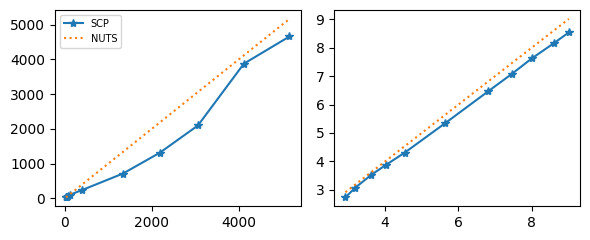

In [12]:
ps = jnp.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.98, 0.99])
plot_indices = [1, p+1]
fig, ax = plt.subplots(1, 2, figsize=(6, 2.5))
for j, idx in enumerate(plot_indices):
    # nuts_quantiles = jnp.quantile(nuts_samples[:, idx], ps)
    nuts_quantiles = results[f'NUTS{idx}'].values
    scp_quantiles = jnp.quantile(scp_samples[:, idx], ps)
    # hmc_quantiles = jnp.quantile(hmc_samples[:, idx], ps)
    # gibbs_quantiles = jnp.quantile(gibbs_samples[:, idx], ps)
    ax[j].plot(nuts_quantiles, scp_quantiles, "*-", label="SCP")
    # ax[j].plot(nuts_quantiles, hmc_quantiles, "o-", label="HMC")
    # ax[j].plot(nuts_quantiles, gibbs_quantiles, "s-", label="Gibbs")
    ax[j].plot(nuts_quantiles, nuts_quantiles, ":", label="NUTS")
ax[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

(array([2.54125461e-03, 2.45749052e-03, 1.53854920e-03, 9.97778107e-04,
        6.86126555e-04, 5.75262084e-04, 4.32370594e-04, 3.88024892e-04,
        2.71001512e-04, 2.21728510e-04, 1.83541795e-04, 1.53978132e-04,
        1.45355247e-04, 1.33037006e-04, 1.20718946e-04, 8.62276890e-05,
        7.63730960e-05, 7.88368628e-05, 6.77503271e-05, 7.39095588e-05,
        4.92729651e-05, 5.66639099e-05, 5.91276471e-05, 5.05047893e-05,
        6.52866788e-05, 5.42003431e-05, 5.42002616e-05, 6.40548547e-05,
        6.03593823e-05, 4.92731133e-05, 1.72455378e-05, 7.26776236e-05,
        4.92729651e-05, 4.80411410e-05, 2.21729010e-05, 8.99231614e-05,
        4.43456686e-05, 1.72455378e-05, 3.69547238e-05, 8.86916040e-05,
        0.00000000e+00, 7.39094477e-06, 2.46364826e-06, 2.46364826e-06,
        0.00000000e+00, 6.15913916e-06, 1.23182413e-06, 1.84773619e-05,
        0.00000000e+00, 1.23182783e-06]),
 array([3.88522196e+00, 8.50655975e+01, 1.66245972e+02, 2.47426346e+02,
        3.28606720e+02

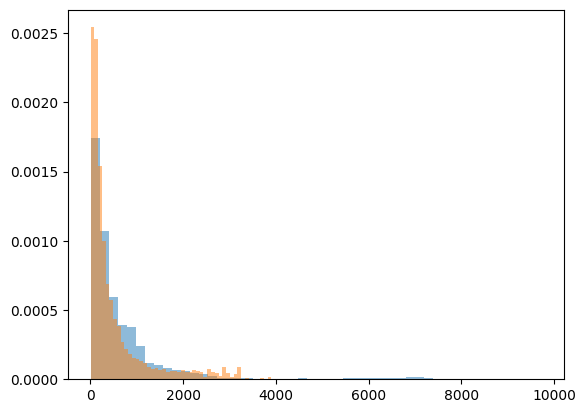

In [115]:
plt.hist(nuts_samples[:, 1], 50, density=True, alpha=0.5)
plt.hist(scp_samples[:, 1], 50, density=True, alpha=0.5)

# Plot results

In [32]:
# savepath = "experiments/results/20260504/logistic_horseshoe/logistic_horseshoe_d20_n50_affinecovariance_lat1.7_stepsize0.005_n500000_seed0_quantiles.csv"
savepath = "experiments/results/20260508/logistic_horseshoe/logistic_horseshoe_d20_n50_affinecovariance_lat1.7_stepsize0.003_n5000000_seed0_quantiles.csv"
results = pd.read_csv(savepath, index_col=0)
results['SCP1']

0.01      41.355550
0.02      56.213547
0.05      96.045490
0.10     140.852650
0.20     206.984860
0.50     543.088870
0.80    1680.433200
0.90    3321.880400
0.95    4672.067400
0.98    5212.055700
0.99    5654.173300
Name: SCP1, dtype: float64

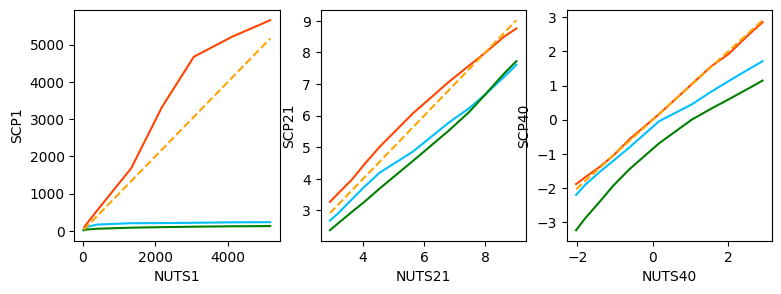

In [27]:
import seaborn as sns

plot_indices = [1, p+1, 2*p]

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for j, idx in enumerate(plot_indices):
    sns.lineplot(results, ax=ax[j], x=f'NUTS{idx}', y=f'SCP{idx}', color='orangered')
    sns.lineplot(results, ax=ax[j], x=f'NUTS{idx}', y=f'HMC{idx}', color='deepskyblue')
    sns.lineplot(results, ax=ax[j], x=f'NUTS{idx}', y=f'Gibbs{idx}', color='green')

    sns.lineplot(results, ax=ax[j], x=f'NUTS{idx}', y=f'NUTS{idx}', color='orange', ls='--')

In [ ]:
sns.set_theme(context='paper', style="whitegrid", font_scale=1.5)
fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharey=True, sharex=True)

sns.lineplot(ax=ax[0], data=gibbs_quantiles, x='ref', y='quantiles', marker='o', linewidth=3, color='green')
ax[0].set_title(fr'Gibbs ($\nu=${int(df)})')

sns.lineplot(ax=ax[1], data=hmc_quantiles, x='ref', y='quantiles', marker='o', linewidth=3, color='deepskyblue')
ax[1].set_title(fr'HMC ($\nu=${int(df)})')

sns.lineplot(ax=ax[2], data=scp_quantiles, x='ref', y='quantiles', marker='o', linewidth=3, color='orangered')
ax[2].set_title(fr'SCS ($\nu=${int(df)})')

for j in range(3):
    ax[j].plot(nuts_quantiles, nuts_quantiles, color='orange', linestyle='-.', lw=3, label='Reference')
    ax[j].set_xlabel('')
    ax[j].set_ylabel('')

# plt.savefig(f'experiments/plots/logistic/{filename_prec}_lat1.1.pdf')